# Projet d'analyse exploratoire : optimisation du matching Tinder

Auteur : Athanor SAVOUILLAN

Contexte : l'équipe marketing de Tinder a constaté une baisse de l'engagement et des matchs.

Objectif : analyser les données issues de sessions de speed dating pour comprendre les facteurs clés qui déclenchent un "deuxième rendez-vous".

Méthodologie :
1. Nettoyage des données
2. Analyse des préférences déclarées vs réelles
3. Étude des facteurs sociologiques (origine, intérêts)
4. Analyse psychologique (perception de soi)
5. Recommandations stratégiques

## 1. Imports et Configuration

Chargement des librairies nécessaires (pandas, numpy, matplotlib, seaborn, plotly) et configuration du template visuel Tinder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Affichage complet des colonnes dans le terminal
pd.set_option('display.max_columns', None)

# Palette de couleurs Tinder
TINDER_PINK = '#FD3476'
TINDER_RED = '#FE5764'
TINDER_ORANGE = '#FF7854'
TINDER_PEACH = '#FFA07A'

# Template Plotly personnalise (fond sombre, couleurs Tinder)
tinder_template = go.layout.Template()
tinder_template.layout = go.Layout(
    paper_bgcolor='#111111',
    plot_bgcolor='#111111',
    font=dict(color='white', family='Arial', size=14),
    title=dict(font=dict(size=20, color='white'), x=0.5),
    xaxis=dict(
        gridcolor='#2A2A2A', linecolor='#444444',
        tickfont=dict(size=12, color='#CCCCCC')
    ),
    yaxis=dict(
        gridcolor='#2A2A2A', linecolor='#444444',
        tickfont=dict(size=12, color='#CCCCCC')
    ),
    legend=dict(
        font=dict(size=13, color='white'),
        bgcolor='rgba(0,0,0,0)'
    ),
    colorway=[TINDER_PINK, TINDER_ORANGE, TINDER_RED, TINDER_PEACH]
)
pio.templates['tinder_dark'] = tinder_template
pio.templates.default = 'tinder_dark'

# Chargement du dataset
try:
    df = pd.read_csv('../data/Speed+Dating+Data.csv', encoding='ISO-8859-1')
    print(f'Dataset charge : {df.shape[0]} lignes, {df.shape[1]} colonnes.')
except FileNotFoundError:
    print('Erreur : fichier introuvable.')

Dataset charge : 8378 lignes, 195 colonnes.


## 2. Préparation et nettoyage des données

Les données brutes contiennent de nombreuses valeurs manquantes (questions auxquelles les participants n'ont pas répondu) et des colonnes peu pertinentes pour notre analyse.

Stratégie retenue :
- Suppression des colonnes contenant plus de 30 % de valeurs manquantes. Ce seuil est un compromis classique en EDA : en dessous, les valeurs peuvent être imputées ; au-dessus, la colonne apporte plus de bruit que de signal.
- Suppression des lignes où des informations critiques (âge, race, religion) sont absentes.

In [2]:
# Taux de valeurs manquantes par colonne
missing_pct = df.isnull().sum() / len(df) * 100

# Colonnes avec plus de 30 % de NaN : trop de bruit
cols_a_supprimer = missing_pct[missing_pct > 30].index

df_clean = df.drop(columns=cols_a_supprimer)
print(f'Colonnes supprimees : {len(cols_a_supprimer)}')

# Suppression des lignes sans age, importance race ou religion
df_clean = df_clean.dropna(subset=['age', 'imprace', 'imprelig'])

print('--- Etat final du dataset ---')
print(f'Lignes restantes : {df_clean.shape[0]}')
print(f'Colonnes restantes : {df_clean.shape[1]}')

Colonnes supprimees : 83
--- Etat final du dataset ---
Lignes restantes : 8267
Colonnes restantes : 112


## 2b. Statistiques descriptives

Distributions individuelles des variables clés avant de passer aux corrélations.

In [3]:
# Statistiques descriptives des variables cles
rating_cols = [
    'attr', 'sinc', 'intel',
    'fun', 'amb', 'shar',
]
print("=== Statistiques descriptives ===")
print(
    df_clean[rating_cols + ['age']]
    .describe()
    .round(2)
)

# Distribution de l'age
fig = px.histogram(
    df_clean, x='age', nbins=30,
    title="Distribution de l'age des participants",
    labels={'age': 'Age', 'count': 'Nombre'},
    color_discrete_sequence=['#FD267A'],
)
fig.update_layout(
    template='plotly_dark',
    paper_bgcolor='#111111',
    plot_bgcolor='#111111',
)
fig.show()

=== Statistiques descriptives ===
          attr     sinc    intel      fun      amb     shar      age
count  8077.00  8003.00  7983.00  7929.00  7569.00  7215.00  8267.00
mean      6.19     7.17     7.36     6.40     6.78     5.47    26.36
std       1.95     1.74     1.55     1.95     1.80     2.15     3.57
min       0.00     0.00     0.00     0.00     0.00     0.00    18.00
25%       5.00     6.00     6.00     5.00     6.00     4.00    24.00
50%       6.00     7.00     7.00     7.00     7.00     6.00    26.00
75%       8.00     8.00     8.00     8.00     8.00     7.00    28.00
max      10.00    10.00    10.00    10.00    10.00    10.00    55.00


### Observations

L'âge moyen est de ~26 ans (médiane 26). La distribution est concentrée entre 22 et 30 ans, avec quelques participants plus âgés. Les notes moyennes vont de 5 à 7 sur 10. L'attirance et l'humour ont les écarts-types les plus élevés — les gens sont plus partagés sur ces critères. Les intérêts communs (`shar`) ont la moyenne la plus basse (~5.2).

## 2c. Détection d'anomalies

Boxplots des notes et de l'âge pour repérer les valeurs aberrantes.

In [4]:
# Boxplots des 6 attributs notes
fig = px.box(
    df_clean[rating_cols].melt(),
    x='variable', y='value',
    title="Detection d'anomalies : notes par attribut",
    labels={
        'variable': 'Attribut',
        'value': 'Note (0-10)',
    },
    color='variable',
    color_discrete_sequence=[
        '#FD267A', '#FF6036', '#FF9A44',
        '#FFD93D', '#A8E6CF', '#5CE1E6',
    ],
)
fig.update_layout(
    template='plotly_dark',
    paper_bgcolor='#111111',
    plot_bgcolor='#111111',
    showlegend=False,
)
fig.show()

# Boxplot de l'age
fig_age = px.box(
    df_clean, y='age',
    title="Detection d'anomalies : age",
    color_discrete_sequence=['#FD267A'],
)
fig_age.update_layout(
    template='plotly_dark',
    paper_bgcolor='#111111',
    plot_bgcolor='#111111',
)
fig_age.show()

### Observations

Les distributions des notes sont relativement symétriques (médiane 5-7). Quelques notes à 0 et 10 mais ce sont des extrêmes valides, pas des erreurs. Côté âge, quelques participants au-delà de 40 ans sortent du lot, mais c'est réaliste pour du speed dating — pas de suppression. Le dataset est propre après le nettoyage initial.

## 3. Analyse statistique avec NumPy

Avant l'exploration visuelle, on calcule la matrice de corrélation entre les 6 attributs notés par les participants. Cette approche utilise `np.corrcoef` (produit matriciel normalisé) et des fonctions Python réutilisables.

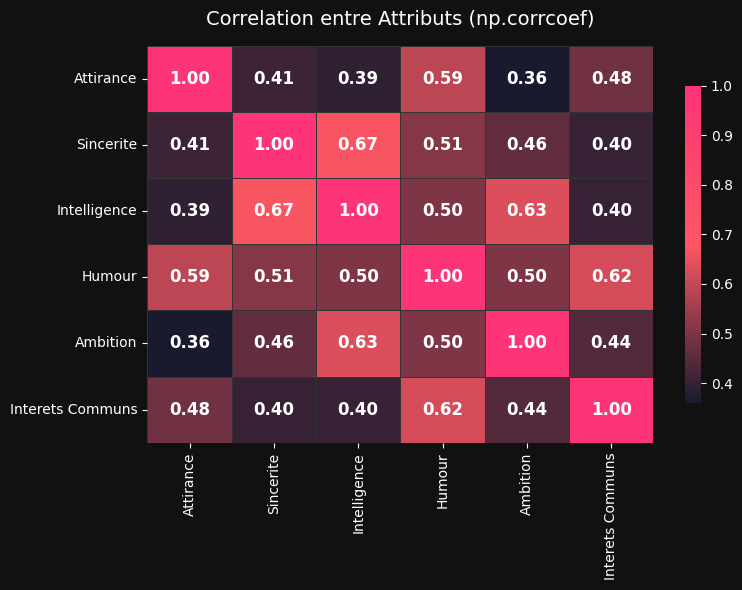


Classement des attributs correles a l'Attirance :
  Humour : 0.59
  Interets Communs : 0.48
  Sincerite : 0.41
  Intelligence : 0.39
  Ambition : 0.36


In [5]:
def correlation_matrix_np(dataframe, cols, labels):
    """Retourne la matrice de correlation
    (np.corrcoef) sous forme de DataFrame.
    """
    data = dataframe[cols].dropna().values
    corr = np.corrcoef(data, rowvar=False)
    return pd.DataFrame(
        np.round(corr, 2),
        index=labels, columns=labels
    )


def rank_attributes(scores_dict):
    """Classe les attributs par score decroissant
    (np.argsort).
    """
    labels = np.array(list(scores_dict.keys()))
    values = np.array(list(scores_dict.values()))
    ranked_idx = np.argsort(values)[::-1]
    return list(zip(
        labels[ranked_idx],
        np.round(values[ranked_idx], 3)
    ))


# Colonnes de notation et labels lisibles
rating_cols = [
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar'
]
rating_labels = [
    'Attirance', 'Sincerite', 'Intelligence',
    'Humour', 'Ambition', 'Interets Communs'
]

corr_mat = correlation_matrix_np(
    df_clean, rating_cols, rating_labels
)

# Heatmap Seaborn avec palette Tinder
tinder_cmap = LinearSegmentedColormap.from_list(
    '', ['#1a1a2e', '#FE5764', '#FD3476']
)

fig_mpl, ax = plt.subplots(
    figsize=(8, 6), facecolor='#111111'
)
ax.set_facecolor('#111111')
sns.heatmap(
    corr_mat, annot=True, fmt='.2f',
    cmap=tinder_cmap, ax=ax,
    linewidths=0.5, linecolor='#333333',
    annot_kws={
        'size': 12, 'color': 'white',
        'weight': 'bold'
    },
    cbar_kws={'shrink': 0.8}
)
ax.set_title(
    'Correlation entre Attributs (np.corrcoef)',
    color='white', fontsize=14, pad=15
)
ax.tick_params(colors='white')
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

# Classement des attributs correles a l'Attirance
attirance_corr = corr_mat['Attirance'].drop(
    'Attirance'
).to_dict()
print(
    '\nClassement des attributs correles'
    " a l'Attirance :"
)
for attr, score in rank_attributes(attirance_corr):
    print(f'  {attr} : {score}')

### Interprétation de la matrice de corrélation

Attirance et Humour présentent la corrélation la plus forte, ce qui confirme que ces deux attributs sont perçus conjointement. Sincérité et Intelligence sont également corrélés, suggérant un profil "sérieux" recherché par certains participants. L'Ambition est relativement indépendante des autres attributs, ce qui en fait un critère de niche.

## 4. Analyse des préférences : ce que les gens disent vouloir

Avant le speed dating, les participants ont noté l'importance de 6 attributs chez un partenaire potentiel : Attirance, Sincérité, Intelligence, Humour, Ambition, Intérêts communs.

Comparons les attentes déclarées des hommes et des femmes.

In [6]:
# Colonnes du questionnaire prealable (importance declaree)
cols_attributes = [
    'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1'
]
cols_names = [
    'Attirance', 'Sincerite', 'Intelligence',
    'Humour', 'Ambition', 'Interets Communs'
]

# Moyenne par genre
avg_attributes = (
    df_clean.groupby('gender')[cols_attributes].mean().reset_index()
)
avg_attributes['gender'] = avg_attributes['gender'].replace(
    {0: 'Femme', 1: 'Homme'}
)

# Passage au format long pour Plotly
data_melted = avg_attributes.melt(
    id_vars='gender', var_name='Attribut',
    value_name='Importance Moyenne'
)
mapping = dict(zip(cols_attributes, cols_names))
data_melted['Attribut'] = data_melted['Attribut'].map(mapping)

fig = px.bar(
    data_melted, x='Attribut', y='Importance Moyenne',
    color='gender', barmode='group',
    title='Attentes Declarees : Hommes vs Femmes',
    color_discrete_map={'Femme': TINDER_PINK, 'Homme': TINDER_ORANGE},
    category_orders={'Attribut': cols_names}
)
fig.update_layout(
    yaxis_title="Points d'importance (sur 100)",
    legend_title_text='Genre',
    bargap=0.2, bargroupgap=0.1
)
fig.show()

### Interprétation des résultats

Le stéréotype se confirme : les hommes déclarent accorder une importance nette à l'attirance physique (barre orange dominante). Les femmes déclarent chercher avant tout l'intelligence, suivie de la sincérité. En revanche, l'ambition et les intérêts communs sont déclarés comme les critères les moins importants par les deux sexes.

## 5. La réalité du terrain : ce qui fait vraiment matcher

Les déclarations sont une chose, les actes en sont une autre. On calcule maintenant la corrélation entre les notes données à un partenaire et la décision finale ("Je veux le/la revoir").

Cela révèle les critères qui influencent réellement la décision.

In [7]:
cols_ratings = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']

# Sous-ensemble : genre, decision, et notes attribuees
df_real = df_clean[['gender', 'dec'] + cols_ratings]

# Correlation de chaque attribut avec la decision finale
correlations = (
    df_real
    .groupby('gender')[cols_ratings + ['dec']]
    .apply(lambda x: x.corrwith(x['dec']))
    .drop(columns=['dec'])
    .reset_index()
)

correlations['gender'] = correlations['gender'].replace(
    {0: 'Femme', 1: 'Homme'}
)
data_corr = correlations.melt(
    id_vars='gender', var_name='Attribut',
    value_name='Impact Reel (Correlation)'
)
mapping_real = {
    'attr': 'Attirance', 'sinc': 'Sincerite',
    'intel': 'Intelligence', 'fun': 'Humour',
    'amb': 'Ambition', 'shar': 'Interets Communs'
}
data_corr['Attribut'] = data_corr['Attribut'].map(mapping_real)

# Ordre decroissant par impact moyen
attr_order = (
    data_corr
    .groupby('Attribut')['Impact Reel (Correlation)']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig = px.bar(
    data_corr, x='Attribut', y='Impact Reel (Correlation)',
    color='gender', barmode='group',
    title='Impact Reel sur la Decision de Match',
    color_discrete_map={'Femme': TINDER_PINK, 'Homme': TINDER_ORANGE},
    category_orders={'Attribut': attr_order}
)
fig.update_layout(
    yaxis_title='Correlation avec la decision',
    legend_title_text='Genre',
    bargap=0.2, bargroupgap=0.1
)
fig.show()

### Interprétation stratégique

Contrairement aux déclarations, l'attirance physique est le critère n°1 pour les femmes également dans la réalité (forte corrélation avec la décision de match). L'humour arrive en deuxième position pour les deux sexes, ce qui en fait le levier comportemental le plus rentable. L'intelligence, bien que réclamée par les femmes dans le questionnaire, a un impact modéré sur la décision immédiate.

Pour maximiser les matchs, la photo de profil (attirance) et la bio (humour) sont les éléments à travailler en priorité.

## 6. Origine vs Passions : levier d'affinité

Faut-il se ressembler pour s'assembler ? On teste deux hypothèses :
1. L'homogamie sociale (même origine ethnique).
2. L'affinité culturelle (intérêts communs).

In [8]:
# Taux de match selon l'origine ethnique
race_impact = df_clean.groupby('samerace')['match'].mean().reset_index()
race_impact['samerace'] = race_impact['samerace'].replace(
    {0: 'Origine Differente', 1: 'Meme Origine'}
)

# Taux de match selon la note d'interets communs
interest_impact = df_clean.groupby('shar')['match'].mean().reset_index()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Impact de l'Origine Ethnique",
        'Impact des Interets Communs'
    ),
    specs=[[{'type': 'bar'}, {'type': 'scatter'}]],
    horizontal_spacing=0.15
)

# Barres : origine ethnique
fig.add_trace(go.Bar(
    x=race_impact['samerace'], y=race_impact['match'],
    marker_color=[TINDER_ORANGE, TINDER_PINK],
    text=[f'{v:.1%}' for v in race_impact['match']],
    textposition='outside',
    textfont=dict(color='white', size=14)
), row=1, col=1)

# Courbe : interets communs
fig.add_trace(go.Scatter(
    x=interest_impact['shar'], y=interest_impact['match'],
    mode='lines+markers', fill='tozeroy',
    line=dict(color=TINDER_PINK, width=3),
    marker=dict(size=8, color=TINDER_RED),
    fillcolor='rgba(253,52,118,0.15)'
), row=1, col=2)

fig.update_layout(
    showlegend=False,
    title_text="Facteurs d'Affinite : Origine vs Passions",
    height=500
)
fig.update_yaxes(
    title_text='Taux de match', tickformat='.0%', row=1, col=1
)
fig.update_yaxes(
    title_text='Taux de match', tickformat='.0%', row=1, col=2
)
fig.update_xaxes(
    title_text='Note interets communs (/10)', row=1, col=2
)

for annotation in fig.layout.annotations:
    annotation.font = dict(size=15, color='white')

fig.show()

### Interprétation des résultats

Côté origine ethnique, l'impact est négligeable : avoir la même origine n'augmente pas significativement la probabilité de match (environ 16 %). Côté intérêts communs, la relation est nette. Avec des intérêts faibles (< 5/10), la probabilité de match est quasi nulle. Au-dessus de 8/10, elle dépasse les 40 %.

Les passions partagées sont un vecteur de connexion bien plus puissant que l'appartenance ethnique.

## 7. Psychologie : perception de soi vs réalité

Les utilisateurs sont-ils lucides sur leur propre attractivité ? On compare la note qu'ils se donnent (auto-évaluation) à la note moyenne qu'ils reçoivent des autres (note réelle).

In [9]:
df_self = df_clean[['attr3_1', 'attr_o']].dropna()
self_perception = (
    df_self.groupby('attr3_1')['attr_o'].mean().reset_index()
)

fig = px.line(
    self_perception, x='attr3_1', y='attr_o', markers=True,
    title='Perception de Soi vs Realite (Attractivite)',
    labels={
        'attr3_1': 'Auto-evaluation',
        'attr_o': 'Note recue en moyenne'
    }
)

fig.update_traces(
    line=dict(color=TINDER_PINK, width=3),
    marker=dict(size=9, color=TINDER_RED)
)

# Diagonale = lucidite parfaite
fig.add_shape(
    type='line', x0=1, y0=1, x1=10, y1=10,
    line=dict(color='#FFFFFF', width=2, dash='dash')
)
fig.add_annotation(
    x=9, y=9.3, text='Lucidite Parfaite',
    font=dict(color='#FFFFFF', size=13), showarrow=False
)

fig.add_annotation(
    x=2.5, y=7.5, text='Sous-estimation',
    font=dict(color=TINDER_ORANGE, size=12), showarrow=False
)
fig.add_annotation(
    x=8.5, y=5, text='Surestimation',
    font=dict(color=TINDER_ORANGE, size=12), showarrow=False
)

fig.update_layout(
    xaxis=dict(range=[1, 10], dtick=1),
    yaxis=dict(range=[1, 10], dtick=1)
)
fig.show()

### Interprétation des résultats

La ligne blanche pointillée représente la lucidité parfaite (je me mets 7, je reçois 7).

Les personnes qui se notent bas (2 à 5) ont tendance à se sous-estimer : la courbe rose passe au-dessus de la diagonale. À l'inverse, celles qui se notent très haut (9-10) se surévaluent par rapport à la réalité, la moyenne reçue plafonne autour de 7/10.

Conséquence : il y a un décalage fréquent entre l'image que les utilisateurs ont d'eux-mêmes et la réception de leur profil.

## 8. Analyse Logistique : L'influence du Timing

Existe-t-il une "fatigue décisionnelle" ? Les participants sont-ils plus severes en fin de soirée après avoir vu 20 personnes ?

In [10]:
order_impact = df_clean.groupby('order')['match'].mean().reset_index()

fig = px.line(
    order_impact, x='order', y='match', markers=True,
    title="Probabilite de Match selon l'Ordre de Passage",
    labels={
        'order': 'Ordre du rendez-vous (1er au 22eme)',
        'match': 'Taux de match'
    }
)

fig.update_traces(
    line=dict(color=TINDER_PINK, width=2),
    marker=dict(size=6, color=TINDER_RED),
    name='Donnees brutes'
)

# Courbe de tendance lissee
fig.add_trace(go.Scatter(
    x=order_impact['order'], y=order_impact['match'],
    mode='lines', name='Tendance',
    line=dict(color=TINDER_ORANGE, width=3, shape='spline')
))

fig.update_layout(
    legend=dict(x=0.02, y=0.98),
    yaxis=dict(tickformat='.1%')
)
fig.show()

### Interprétation des résultats

La courbe ne montre aucune chute significative du taux de match au fil de la soirée. On observe même un léger rebond d'intérêt lors des derniers rendez-vous (effet "dernière chance" ?). L'ordre de passage n'est pas un facteur discriminant.

# Conclusion et recommandations

Cette analyse portant sur plus de 8 000 rendez-vous débouche sur quatre recommandations pour améliorer le taux de match :

- Miser sur le visuel (photo) : c'est le facteur déclencheur n°1 pour tous les genres, malgré les discours contraires.
- Encourager l'humour : c'est le levier comportemental le plus rentable en termes de matchs.
- Valoriser les hobbies plutôt que l'origine : les intérêts communs notés au-dessus de 8/10 produisent un taux de match 2.5x supérieur à l'homogamie ethnique. L'algorithme devrait prioriser les passions partagées.
- Proposer du coaching profil : le décalage entre perception de soi et réalité est systématique. Un feedback personnalisé aiderait les utilisateurs à mieux se positionner.

Point annexe : l'ordre de passage n'a pas d'impact significatif sur le taux de match (pas de fatigue décisionnelle détectée).